# XRD Spectrum Analysis

This notebook loads and displays the experimental XRD spectrum from the available .ASC file.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Find the workspace root by searching for the 'data' folder from the current notebook working directory upward.
current_path = Path.cwd().resolve()
workspace_root = None
for parent in [current_path] + list(current_path.parents):
    if (parent / 'data' / 'XRD' / '2 Round').exists():
        workspace_root = parent
        break

if workspace_root is None:
    workspace_root = current_path
    print('Warning: Could not locate workspace root automatically; using current working directory.')

xrd_folder = workspace_root / 'data' / 'XRD' / '2 Round'
print(f'Searching for XRD data in: {xrd_folder}')

# Choose the exact ASC files you want to plot.
# If selected_files is empty, all ASC files in the folder will be loaded.
selected_files = [
    'Mo_room_25Se_400Sb_35Se.ASC',
    'Mo_400deg_25Se_400Sb_35Se.ASC',
    'Mo_400Sb_30Se.ASC',
    'Mo_300Sb_35Se.ASC',
    'Mo_200Sb_25Se.ASC',
]

if selected_files:
    xrd_files = [xrd_folder / filename for filename in selected_files]
else:
    xrd_files = sorted(xrd_folder.glob('*.ASC'))

spectra = []
for xrd_file in xrd_files:
    if xrd_file.exists():
        data = np.loadtxt(xrd_file)
        theta = data[:, 0]
        intensity = data[:, 1]
        spectra.append((xrd_file.name, theta, intensity))
        print(f'Loaded {xrd_file.name}: {len(theta)} points, 2θ range {theta.min():.2f}°–{theta.max():.2f}°')
    else:
        print(f'File not found: {xrd_file.name}')

if not spectra:
    print('No XRD spectra were loaded. Please verify the files exist in data/XRD/2 Round.')
else:
    print(f'Total spectra loaded: {len(spectra)}')

Searching for XRD data in: C:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\data\XRD\2 Round
Loaded Mo_room_25Se_400Sb_35Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Loaded Mo_400deg_25Se_400Sb_35Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Loaded Mo_400Sb_30Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Loaded Mo_300Sb_35Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Loaded Mo_200Sb_25Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Total spectra loaded: 5


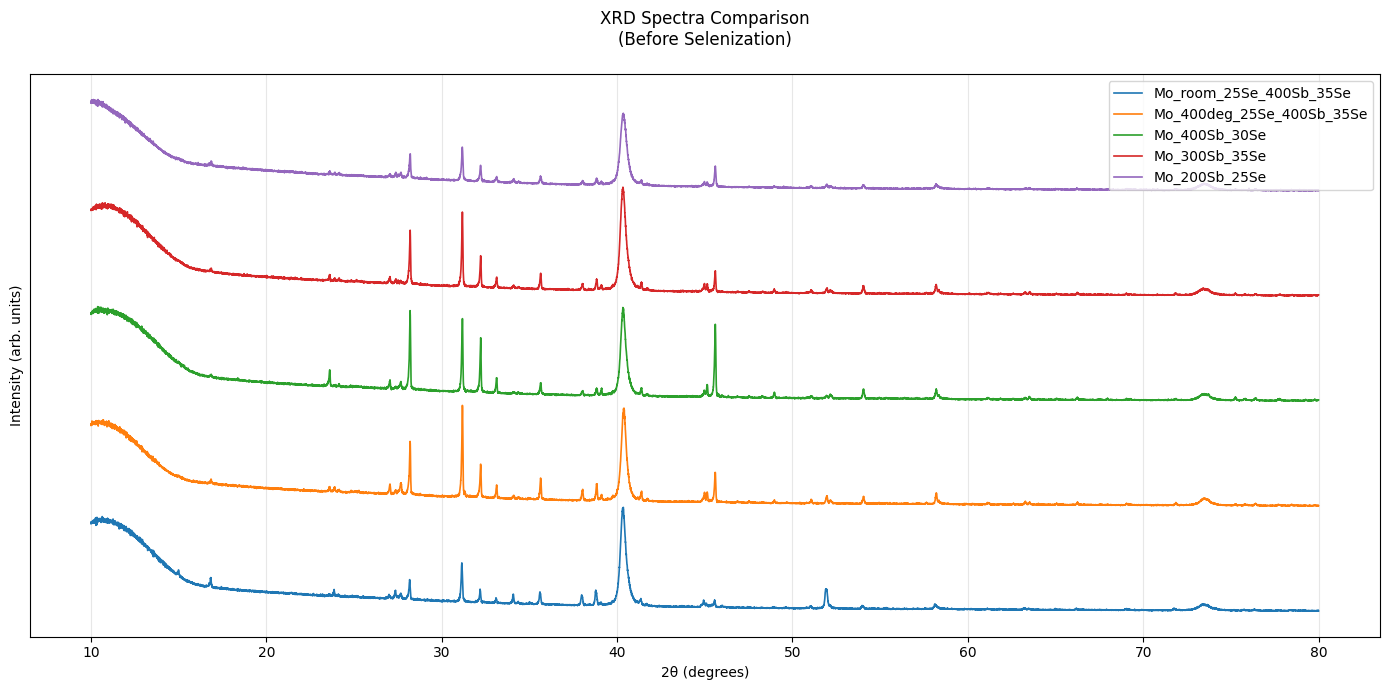

In [3]:
if spectra:
    plt.figure(figsize=(14, 7))
    colors = plt.cm.tab10.colors
    offset_step = 10000
    for index, (name, theta, intensity) in enumerate(spectra):
        offset = index * offset_step
        color = colors[index % len(colors)]
        plt.plot(theta, intensity + offset, linewidth=1.2, label=f"{name.replace('.ASC', '')}", color=color)

    plt.title('XRD Spectra Comparison\n(Before Selenization)\n')
    plt.xlabel('2θ (degrees)')
    plt.ylabel('Intensity (arb. units)')
    plt.yticks([])
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('No spectrum data available to plot.')